# **Machine Learning Model steps**


1. Import all libraries like numpy,pandas,tensor/keras, sklearn
2. Import Data using pandas, pd.read_csv
3. EDA or prepocessing like encoding, transforming
4. Data Cleaning
5. Make target variables x and y then divide data into two parts:- training , testing using train_test_split in ratio 8:2 o 7:3
6. Import ML model
7. Fit training data into model using model.fit()
8. Predict using the data using .predict function:- model.predict(data)
9. Check the evaluation:- R2 score,F1 score, accuracy
10. Convert model into pkl file
11. Making the GUI.
12. Pkl file adjusts into GUI code.



In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix
import pickle
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor,plot_tree

# *Importing and Cleaning the Data*

In [ ]:
df=pd.read_csv('/content/salary_data.csv')
df.head()
print(df.isnull().sum())

YearsExperience    0
Salary             0
dtype: int64


In [ ]:
df.dropna(inplace=True)
print(df.isnull().sum())

YearsExperience    0
Salary             0
dtype: int64


In [ ]:
x=df[['YearsExperience']]
y=df[['Salary']]
print(len(x))
print(len(y))

30
30


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(len(x_train))
print(len(x_test))

24
6


In [ ]:
dtr=DecisionTreeRegressor()
dtr.fit(x_train,y_train)
y_pred=dtr.predict(x_test)



# Implementing RandomSearchCV and finding the best hyperparameters

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
n_estimators=[int(x) for x in np.linspace(start=100,stop=100,num=10)]
max_depth=[int(x) for x in np.linspace(5,30,num=6)]
min_samples_split=[2,5,10,15,100]
min_samples_leaf=[1,2,5,10]
bootstrap=[True,False]
random_search={'n_estimators':n_estimators,
               'max_depth':max_depth,
               'min_samples_split':min_samples_split,
               'min_samples_leaf':min_samples_leaf,
               'bootstrap':bootstrap}
rf=RandomForestRegressor()
rf_random=RandomizedSearchCV(estimator=rf,param_distributions=random_search,n_iter=100,cv=3,verbose=2,random_state=42,n_jobs=-1)
rf_random.fit(x_train,y_train)
y_pred=rf_random.predict(x_test)

Fitting 3 folds for each of 100 candidates, totalling 300 fits


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [ ]:
best_random_grid=rf_random.best_params_
print(best_random_grid)

{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 25, 'bootstrap': True}


Got best parameters for randomforest as {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 25, 'bootstrap': True}

In [ ]:
rf=RandomForestRegressor(n_estimators= 100, min_samples_split= 2, min_samples_leaf= 2, max_depth= 25, bootstrap= True)
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [ ]:
y_pred=pd.DataFrame(y_pred)
y_pred.head()

,0
0,115276.896631
1,63039.243548
2,102736.617643
3,70144.981500
4,58032.331560


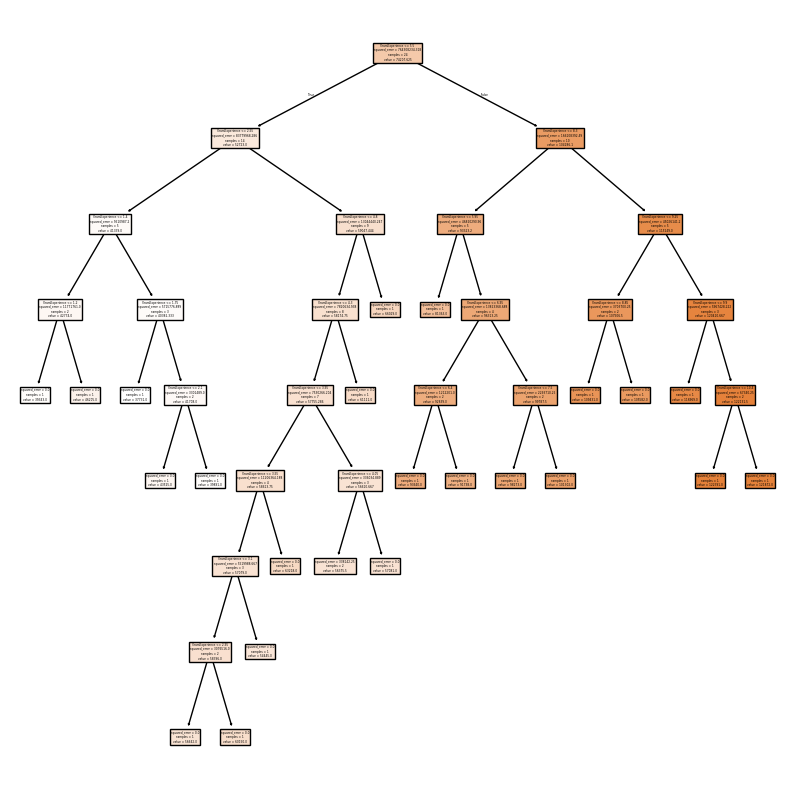

In [ ]:
plt.figure(figsize=(10,10))
plot_tree(dtr,filled=True,feature_names=['YearsExperience'])
plt.show()


# **Saving the model using pickle**

In [ ]:
with open("salary_model.pkl", "wb") as file:
    pickle.dump(lr, file)

print("Model Saved Successfully!")

Model Saved Successfully!


# Loading the **model**

In [ ]:
with open('salary_model.pkl',"rb")as f:
  model=pickle.load(f)

y=bx+c, b= biasness, c=coefficient, :- linear regression
Logistic Regression:- uses categorical data , gives output in binary format,uses sigmoid function if value comes greater than 0.5 then 1 else 0 as a output


# Accuracy= TP+TN/TP+TN+FP+FN

# Precision=TP/TP+F



# Recall=TP/TP+FN

# F1_score = 2PR/P+R

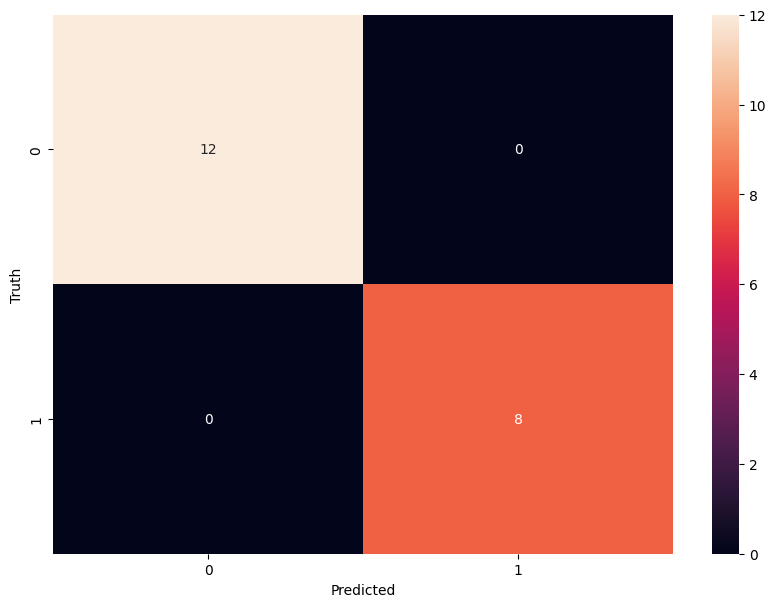

In [ ]:
matrix=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(matrix,annot=True,fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()